#### Imports

In [1]:
import numpy as np 
import pandas as pd 

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [2]:
from pathlib import Path 
import zipfile
from zipfile import ZipFile 
import torch

#### Download data

In [3]:
data_path = Path("data")
file_path = data_path / "digit_recognizer"
file_path_zip = data_path / "digit-recognizer.zip"

with zipfile.ZipFile(file_path_zip, "r") as ref_zip:
    print(f"Unzipping digit recognizer data in {file_path}...")
    ref_zip.extractall(file_path)

Unzipping digit recognizer data in data/digit_recognizer...


#### Transformation data

In [4]:
# train_df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")
# test_df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/test.csv")

train_path = file_path / "train.csv"
test_path = file_path / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X_train_np = train_df.drop(columns=["label"]).values
y_train_np = train_df["label"].values
X_test_np = test_df.values

X_train = torch.tensor(X_train_np, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(X_test_np, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0 

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: torch.Size([42000, 1, 28, 28])
y_train shape: torch.Size([42000])
X_test shape: torch.Size([28000, 1, 28, 28])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test)

train_dataset, test_dataset

(<torch.utils.data.dataset.TensorDataset at 0x115980670>,
 <torch.utils.data.dataset.TensorDataset at 0x115980460>)

#### Visualization data

In [19]:
import random 
import matplotlib.pyplot as plt 

def plot_images(data: torch.utils.data,
                n: int = 3,
                seed=2026):
    random.seed(2026)
    random_indexes = random.sample(range(len(data)), k=n)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))

    for ax, index in zip(axes, random_indexes):
        img, label = data[index]
        class_name = label.item()

        ax.imshow(img.permute(1, 2, 0), cmap="gray")
        ax.set_title(f"Class: {class_name}", fontsize=15)
        ax.axis(False)
    plt.tight_layout()
    plt.show();

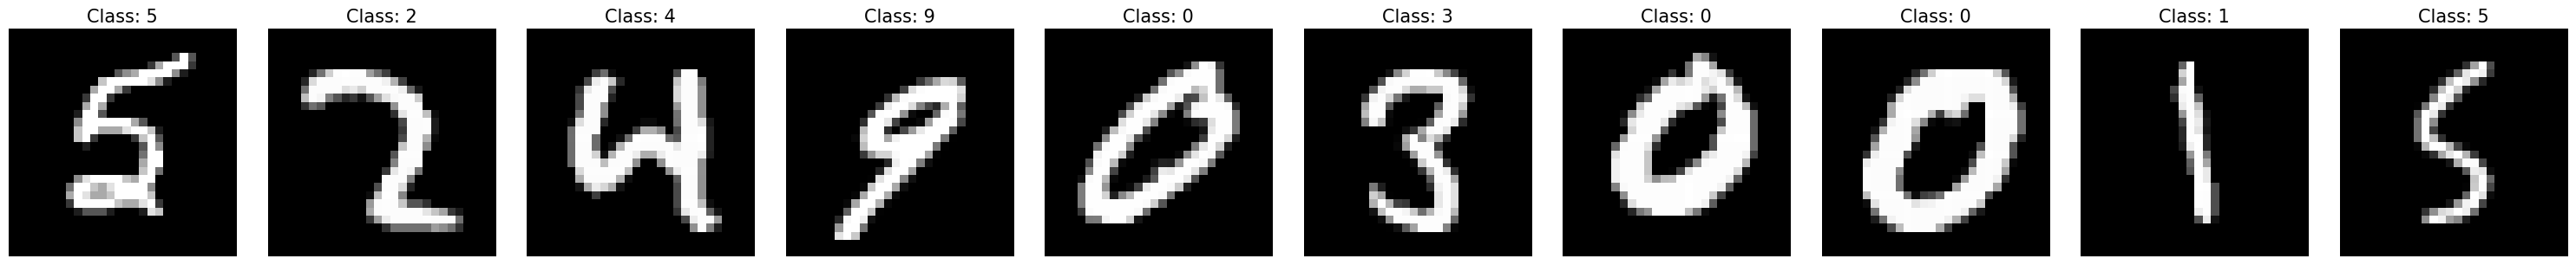

In [20]:
plot_images(data=train_dataset,
            n=10,
            )